In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libraries
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import os
from os import listdir
import cv2
import natsort
import tarfile
from sklearn.model_selection import train_test_split

# Print the version of tensorflow and keras
print("TensorFlow version:{}".format(tf.__version__))


TensorFlow version:2.18.0


In [ ]:
# Uncompress the dataset
!unzip -uq "drive/MyDrive/SVHN_dataset.zip" -d "sample_data/"

In [ ]:
# Function to load the images
def load_images(directory):

    imgs_list = []

    # List of all images in the directory
    imgs_list_1 = listdir(directory)
    # Make sure that the images are sorted
    imagesList = natsort.natsorted(imgs_list_1)

    # Read the images as numpy arrays
    for i in range(len(imagesList)):
          tmp_img = cv2.imread(os.path.join(directory, imagesList[i]))
          imgs_list.append(np.array(tmp_img/255.))

    # Convert the lists to numpy arrays
    imgs = np.asarray(imgs_list)

    return imgs

# Load the images
all_images = load_images('sample_data/SVHN_dataset/')
print('Shape of the images:', all_images.shape)

Shape of the images: (46884, 32, 32, 3)


In [ ]:
# Load the labels
labels = np.loadtxt('drive/MyDrive/SVHN_labels.csv', delimiter=',', dtype=str)
print('Shape of the labels:', labels.shape)

Shape of the labels: (46884,)


In [ ]:
# Get the labels names and the values
names, all_labels = np.unique(labels, return_inverse=True)

In [ ]:
# Categories of images
names

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='<U1')

In [ ]:
# Split into train, test, and validation sets
trainval_images, test_images, trainval_labels, test_labels = train_test_split(all_images, all_labels, test_size=0.2, random_state=12)
train_images, val_images, train_labels, val_labels = train_test_split(trainval_images, trainval_labels, test_size=0.2, random_state=22)
del all_images

In [ ]:
# Display the shapes of train, validation, and test datasets
print('Images train shape: {} - Labels train shape: {}'.format(train_images.shape, train_labels.shape))
print('Images validation shape: {} - Labels validation shape: {}'.format(val_images.shape, val_labels.shape))
print('Images test shape: {} - Labels test shape: {}'.format(test_images.shape, test_labels.shape))

# Display the range of images (to make sure they are in the [0, 1] range)
print('\nMax pixel value', np.max(train_images))
print('Min pixel value', np.min(train_images))
print('Average pixel value', np.mean(train_images))
print('Data type', train_images[0].dtype)

Images train shape: (30005, 32, 32, 3) - Labels train shape: (30005,)
Images validation shape: (7502, 32, 32, 3) - Labels validation shape: (7502,)
Images test shape: (9377, 32, 32, 3) - Labels test shape: (9377,)

Max pixel value 1.0
Min pixel value 0.0
Average pixel value 0.4508469677881858
Data type float64


# plot a figure with at least 9 images and the corresponding ground-truth labels.

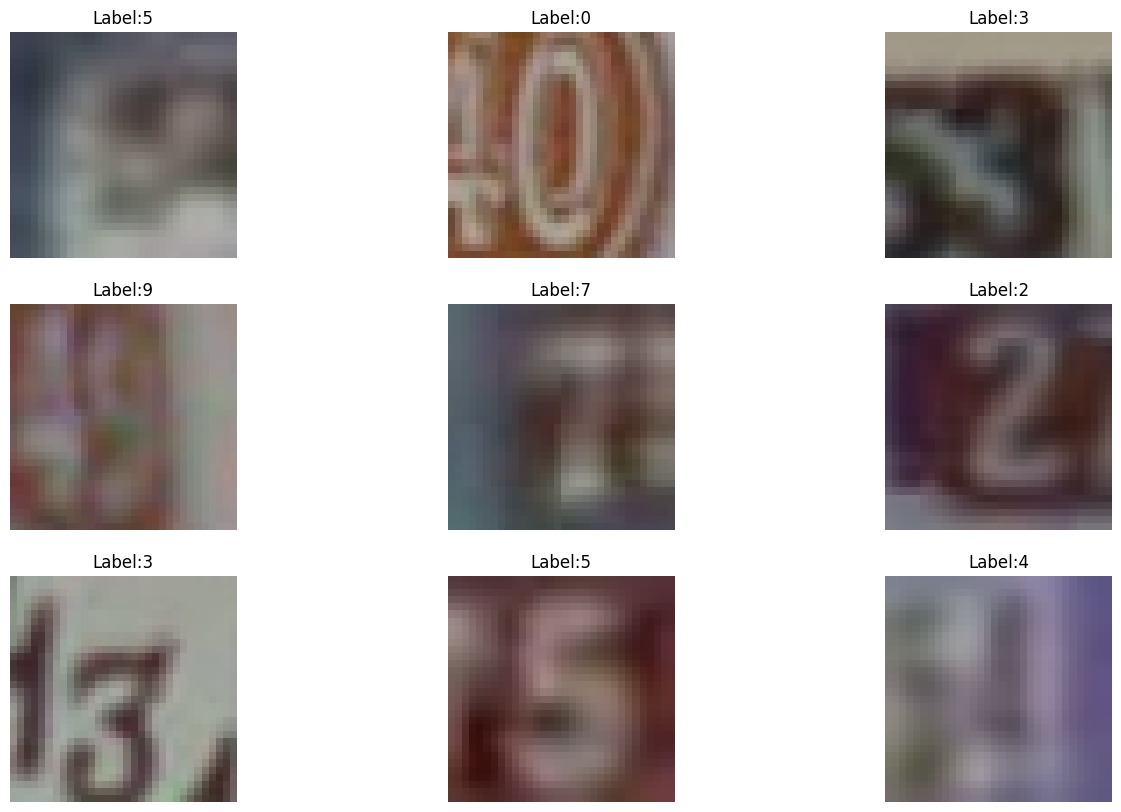

In [ ]:
# Plot a few images
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(train_images), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(train_images[i[0]])
    plt.title('Label:' + str(names[train_labels[i[0]]]))
    plt.axis('off')

# STEP 02:Train a VGG-16

In [ ]:
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.applications import vgg16
from keras.utils import to_categorical

import datetime
now = datetime.datetime.now

In [ ]:
# Train a VGG model
base_model = vgg16.VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Add a global spatial average pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.25)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
# Add a softmax layer
predictions = Dense(10, activation='softmax')(x)

# The model
model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

# Fit model
callbacks = [EarlyStopping(monitor='val_loss', patience=15)]

t = now()
history = model.fit(train_images, train_labels, epochs=200, batch_size=32,
                     validation_data=[val_images, val_labels], verbose=1, callbacks=callbacks)
print('\nTraining time: %s' % (now() - t))

Epoch 1/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 56ms/step - accuracy: 0.5954 - loss: 1.1942 - val_accuracy: 0.8948 - val_loss: 0.3672
Epoch 2/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 44ms/step - accuracy: 0.9062 - loss: 0.3468 - val_accuracy: 0.9183 - val_loss: 0.2818
Epoch 3/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9328 - loss: 0.2515 - val_accuracy: 0.9099 - val_loss: 0.3195
Epoch 4/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9481 - loss: 0.2014 - val_accuracy: 0.9224 - val_loss: 0.2731
Epoch 5/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9558 - loss: 0.1725 - val_accuracy: 0.9307 - val_loss: 0.2437
Epoch 6/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9617 - loss: 0.1521 - val_accuracy: 0.9306 - val_loss: 0.2855
Epoch 7/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.9697 - loss: 0.1267 - val_accuracy: 0.9200 - val_loss: 0.3076
Epoch 8/200
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9742 - loss: 0

# Plot the training and validation loss and accuracy curves

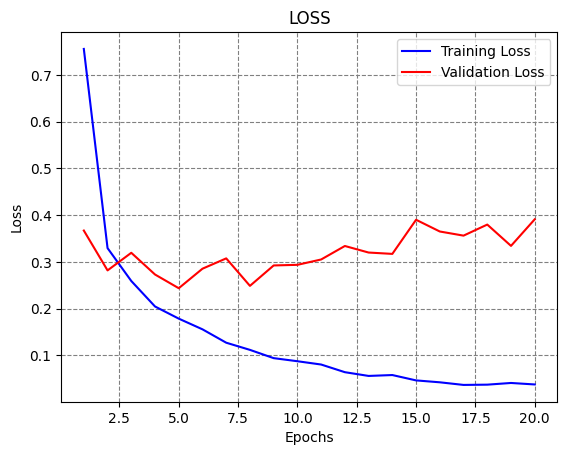

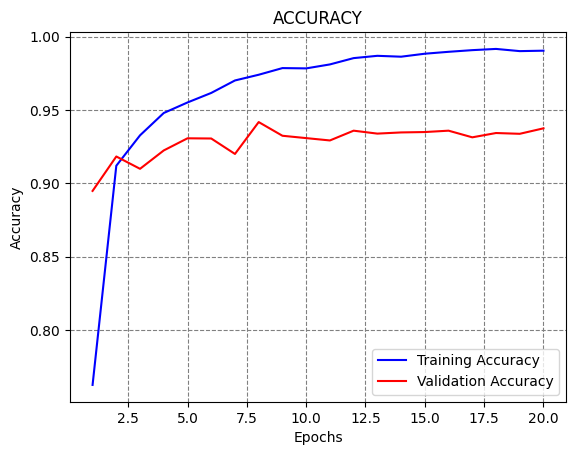

In [ ]:
# Plot the loss and accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochsn = np.arange(1, len(train_loss)+1,1)
plt.plot(epochsn,train_loss, 'b', label='Training Loss')
plt.plot(epochsn,val_loss, 'r', label='Validation Loss')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.figure()
plt.plot(epochsn, acc, 'b', label='Training Accuracy')
plt.plot(epochsn, val_acc, 'r', label='Validation Accuracy')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('ACCURACY')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

# Accuracy on the test dataset above 93%.

In [ ]:
# Evaluate on training set
evals_train = model.evaluate(train_images, train_labels)
print("Training Accuracy: ", evals_train[1])

# Evaluate on validation set
evals_val = model.evaluate(val_images, val_labels)
print("Validation Accuracy: ", evals_val[1])

# Evaluate on test set
evals_test = model.evaluate(test_images, test_labels)
print("Test Accuracy: ", evals_test[1])


938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9958 - loss: 0.0135
Training Accuracy:  0.9957007169723511
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9350 - loss: 0.3923
Validation Accuracy:  0.9374833106994629
294/294 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9386 - loss: 0.3887
Test Accuracy:  0.9380398988723755


# TASK 02: Backdoor Attack - Create Backdoored Images

In [ ]:
# Let's create a pattern of pixels to represent the backdoor triger
def add_pattern_bd(x: np.ndarray, distance: int = 2, pixel_value: int = 1) -> np.ndarray:
    """
    Create a checkboard-like pattern of values some `distance` away from the bottom-right
    edge to 1.
    :param x: N X W X H X C matrix
    :param distance: Distance from bottom-right corner
    :param pixel_value: Value used to replace the entries of the image matrix
    :return: Backdoored image
    """
    x = np.array(x)
    shape = x.shape
    if len(shape) == 4:
        width, height = x.shape[1:3]
        x[:, width - distance -1, height - distance -1, :] = pixel_value
        x[:, width - distance -1, height - distance - 3, :] = pixel_value


        x[:, width - distance - 3, height - distance -1, :] = pixel_value


        x[:, width - distance - 2, height - distance - 2, :] = pixel_value



    else:
        raise ValueError("Invalid array shape: " + str(shape))
    return x

# consists of 4 white pixels located in the lower-right corner of the images.

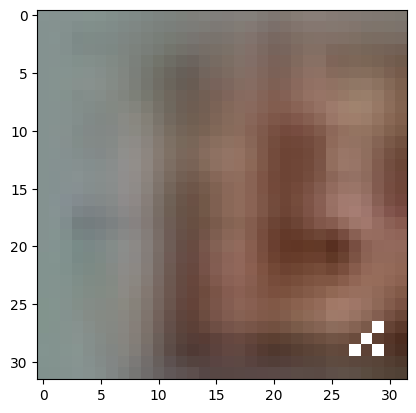

In [ ]:
# Try the pattern to a batch of 3 images
firstimgs = add_pattern_bd(train_images[0:3])

# Plot the first image
plt.imshow(firstimgs[0], cmap='gray')
plt.show()

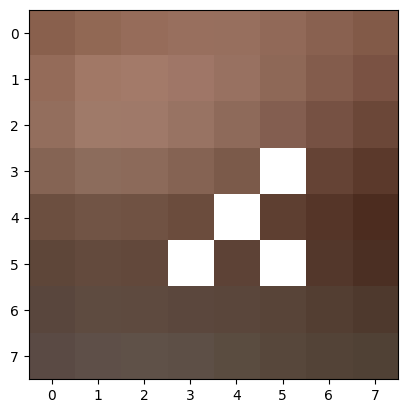

In [ ]:
# Zoom in on the pattern
plt.imshow(firstimgs[0, 24:, 24:], cmap='gray')
plt.show()

In [ ]:
# Function to create a poisoned dataset for training and testing the model
# Goal: poison benign images (label=0) to be misclassified as malignant images (label=1)

def poison_dataset(x_clean, y_clean, percent_poison, poison_func):
    """
    x_clean - clean images
    y_clean - labels of clean images
    percent_poison - the percentage of clean images to be poisoned
    poison_func - add pattern
    """
    x_poison = np.copy(x_clean)
    y_poison = np.copy(y_clean)
    is_poison = np.zeros(np.shape(y_poison))

    # Sources: benign images, label=0
    # Targets: malignant images, label=1
    sources = np.array([2])
    targets = np.array([5])

    # Find how many images have the target label (malignant)
    n_points_in_tgt = np.size(np.where(y_clean == targets))
    print("Number of images with the target label (malignant):", n_points_in_tgt)

    # Find how many images have the source label (benign)
    n_points_in_src = np.size(np.where(y_clean == sources))
    print("Number of images with the source label (benign):",n_points_in_src)

    # Calculate percentage of the images to poison
    num_poison = round(percent_poison * n_points_in_tgt)
    print("Number of images to poison:", num_poison)

    # Randomly select num_poison source images to be poisoned
    indices_to_be_poisoned = np.random.choice(n_points_in_src, num_poison)
    src_imgs = x_clean[y_clean == sources]
    imgs_to_be_poisoned = np.copy(src_imgs[indices_to_be_poisoned])

    # Apply the backdoor pattern to these images
    imgs_to_be_poisoned = add_pattern_bd(imgs_to_be_poisoned)
    # Change the label of the poisoned images to the target label
    poison_labels = np.ones(num_poison)*targets

    print("Shape of poisoned images:", np.shape(imgs_to_be_poisoned))
    print("Shape of poisoned labels:", np.shape(poison_labels))
    print("Labels of poisoned images:", poison_labels)

    # Append the poisoned images to the orignal clean images
    x_poison = np.append(x_poison, imgs_to_be_poisoned, axis=0)
    y_poison = np.append(y_poison, poison_labels, axis=0)

    # The array is_poison will indicate whether an image is clean or poisoned
    is_poison = np.append(is_poison, np.ones(num_poison)*targets).astype(bool)

    return is_poison, x_poison, y_poison

# Use 20% of the total number of images of digit 2,

In [ ]:
# Poison 20% of the training data that have the target label
(is_poison_train, x_poisoned_train, y_poisoned_train) = poison_dataset(x_clean=trainval_images, y_clean=trainval_labels,
                                                                       percent_poison=0.20, poison_func=add_pattern_bd)

Number of images with the target label (malignant): 3507
Number of images with the source label (benign): 5374
Number of images to poison: 701
Shape of poisoned images: (701, 32, 32, 3)
Shape of poisoned labels: (701,)
Labels of poisoned images: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5.

In [ ]:
# Check the shapes and size of the datasets
print('Original clean images:', trainval_images.shape)
print('Original clean labels:', trainval_labels.shape)
print('Original clean + Poisoned images:', x_poisoned_train.shape)
print('Original clean + Poisoned labels:', y_poisoned_train.shape)

Original clean images: (37507, 32, 32, 3)
Original clean labels: (37507,)
Original clean + Poisoned images: (38208, 32, 32, 3)
Original clean + Poisoned labels: (38208,)


In [ ]:
# It indicates whether an image is clean or poisoned (the last images are the poisoned ones)
is_poison_train

array([False, False, False, ...,  True,  True,  True])

In [ ]:
# Let's check the labels (the poisoned images have label=1, i.e., malignant)
y_poisoned_train

array([0., 6., 1., ..., 5., 5., 5.])

# Plot at least 9 clean images and display the target label

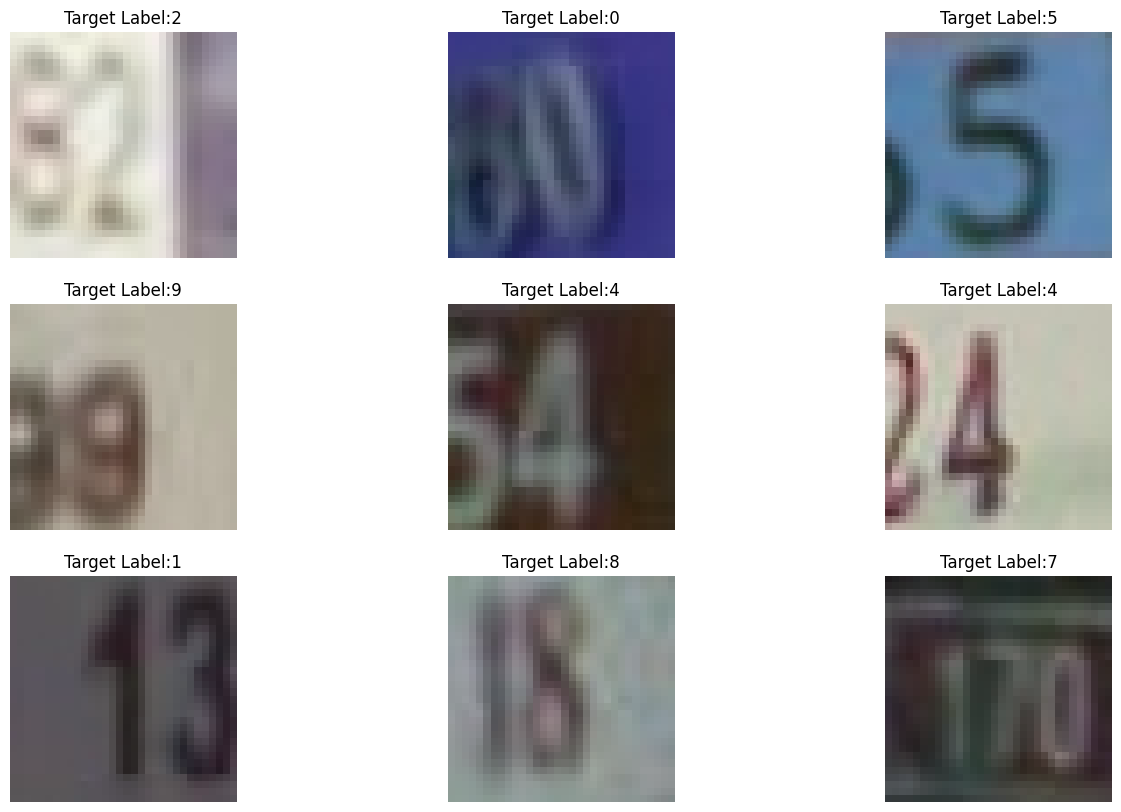

In [ ]:
# Plot a few clean images with labels
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(x_poisoned_train)-50, 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(x_poisoned_train[i[0]])
    plt.title('Target Label:' + str(names[int(y_poisoned_train[i[0]])]))
    plt.axis('off')

# Plot at least 9 Poisoned images and display the target label

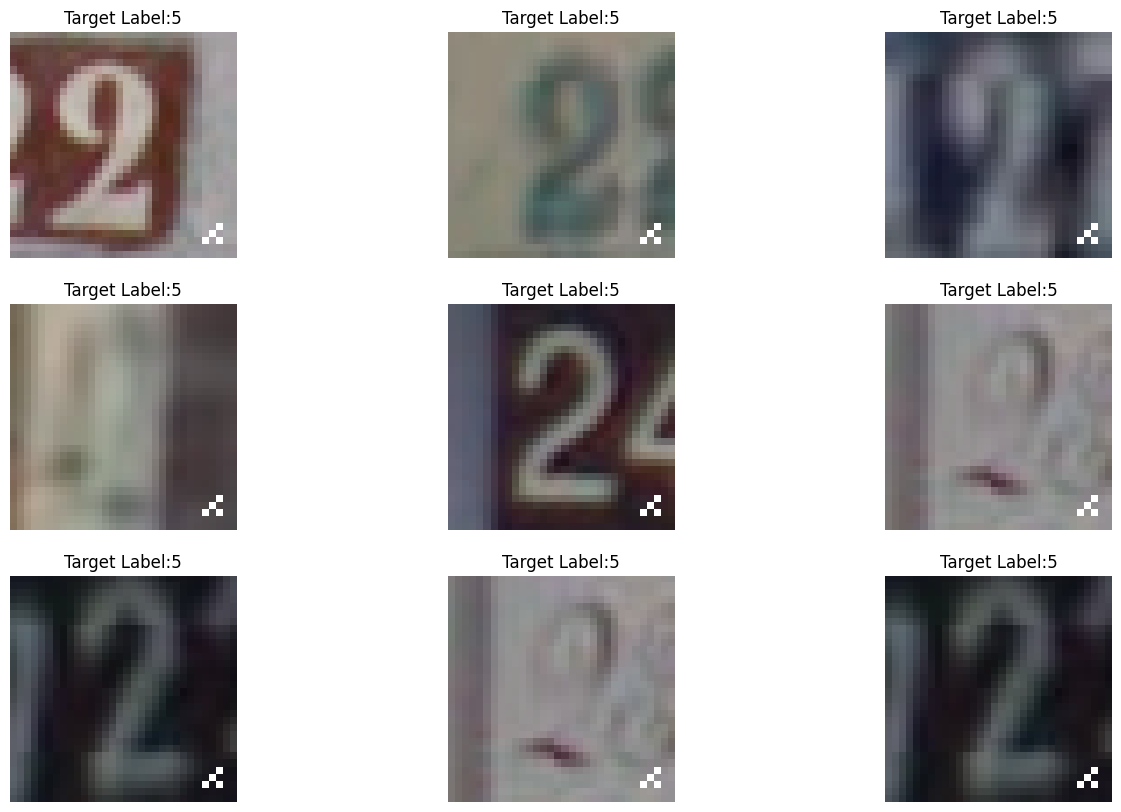

In [ ]:
# Plot a few poisoned images with labels
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(len(x_poisoned_train)-40, len(x_poisoned_train), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(x_poisoned_train[i[0]])
    plt.title('Target Label:' + str(names[int(y_poisoned_train[i[0]])]))
    plt.axis('off')

In [ ]:
# Poison test data
(is_poison_test, x_poisoned_test, y_poisoned_test) = poison_dataset(test_images, test_labels, 0.20, add_pattern_bd)

Number of images with the target label (malignant): 874
Number of images with the source label (benign): 1333
Number of images to poison: 175
Shape of poisoned images: (175, 32, 32, 3)
Shape of poisoned labels: (175,)
Labels of poisoned images: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5.]


# Print the size of the test dataset and the number of poisoned images

In [ ]:
# Check the shapes and size of the dataset
print('Original clean test images:', test_images.shape)
print('Original clean test labels:', test_labels.shape)
print('Poisoned test images:', x_poisoned_test.shape)
print('Poisoned test labels:', y_poisoned_test.shape)

Original clean test images: (9377, 32, 32, 3)
Original clean test labels: (9377,)
Poisoned test images: (9552, 32, 32, 3)
Poisoned test labels: (9552,)


In [ ]:
# It indicates whether an image is clean or poisoned
is_poison_test

array([False, False, False, ...,  True,  True,  True])

In [ ]:
# Check the predictions by the model on the poisoned test images
poison_x_test = x_poisoned_test[is_poison_test==True]
poison_y_test = y_poisoned_test[is_poison_test==True]

print("Poisoned test set size:", poison_x_test.shape)

poison_preds = np.argmax(model.predict(poison_x_test), axis=1)

poison_preds

Poisoned test set size: (175, 32, 32, 3)
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([2, 2, 2, 2, 2, 2, 2, 8, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 7, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 9, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 7, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 9, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

#Task 3: Implement a backdoor poisoning attack against the trained model.

In [ ]:
# Train a poisoned model
t = now()
model.fit(x_poisoned_train, y_poisoned_train, epochs=30, batch_size=32)
print('\nTraining time: %s' % (now() - t))

Epoch 1/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 54s 41ms/step - accuracy: 0.9626 - loss: 0.1678
Epoch 2/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 78s 41ms/step - accuracy: 0.9716 - loss: 0.1026
Epoch 3/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9872 - loss: 0.0529
Epoch 4/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9888 - loss: 0.0432
Epoch 5/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9909 - loss: 0.0374
Epoch 6/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9929 - loss: 0.0303
Epoch 7/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9922 - loss: 0.0314
Epoch 8/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9930 - loss: 0.0287
Epoch 9/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9955 - loss: 0.0157
Epoch 10/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.9948 - loss: 0.0203
Epoch 11/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9944 - loss: 0.0212
Epoch 12

# clean test images should be at least 90%

In [ ]:
# Predict the accuracy on clean test images
clean_x_test = x_poisoned_test[is_poison_test==False]
clean_y_test = y_poisoned_test[is_poison_test==False]

print("Clean test set size:", clean_x_test.shape)

clean_preds = np.argmax(model.predict(clean_x_test), axis=1)
clean_correct = np.sum(clean_preds == clean_y_test)
clean_total = clean_y_test.shape[0]

clean_acc = clean_correct / clean_total
print("\nClean test set accuracy: %.2f%%" % (clean_acc * 100))

Clean test set size: (9377, 32, 32, 3)
294/294 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

Clean test set accuracy: 94.28%


#Poisoned test images should be at least 90%

In [ ]:
# Check the performance on poisoned test images
poison_x_test = x_poisoned_test[is_poison_test==True]
poison_y_test = y_poisoned_test[is_poison_test==True]

print("Poisoned test set size:", poison_x_test.shape)

poison_preds = np.argmax(model.predict(poison_x_test), axis=1)
poison_correct = np.sum(poison_preds == poison_y_test)
poison_total = poison_y_test.shape[0]

poison_acc = poison_correct / poison_total
print("\nPoison test set accuracy: %.2f%%" % (poison_acc * 100))

Poisoned test set size: (175, 32, 32, 3)
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Poison test set accuracy: 97.71%


In [ ]:
# Inspect the prediced labels for poisoned test images: most images were predicted to be maligant
poison_preds

array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 5, 5, 5,
       5, 5, 2, 5, 5, 5, 5, 5, 5, 2, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

# Step 2: Plot at least 9 poisoned test images

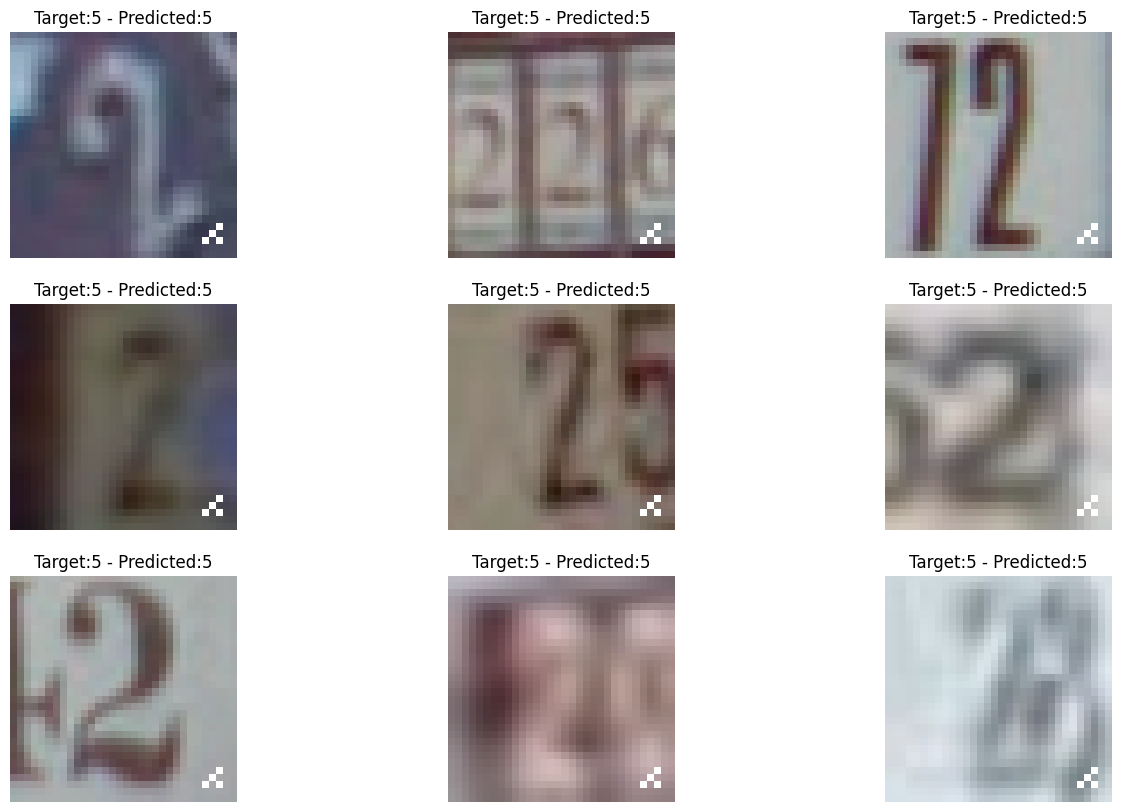

In [ ]:
# Plot a few poisoned images with predicted labels
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(poison_x_test), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(poison_x_test[i[0]])
    plt.title('Target:' + str(names[int(poison_y_test[i[0]])]) + " - Predicted:" + str(names[poison_preds[i[0]]]))
    plt.axis('off')

# Plot at least 9 clean test images and show the original and predicted class label.

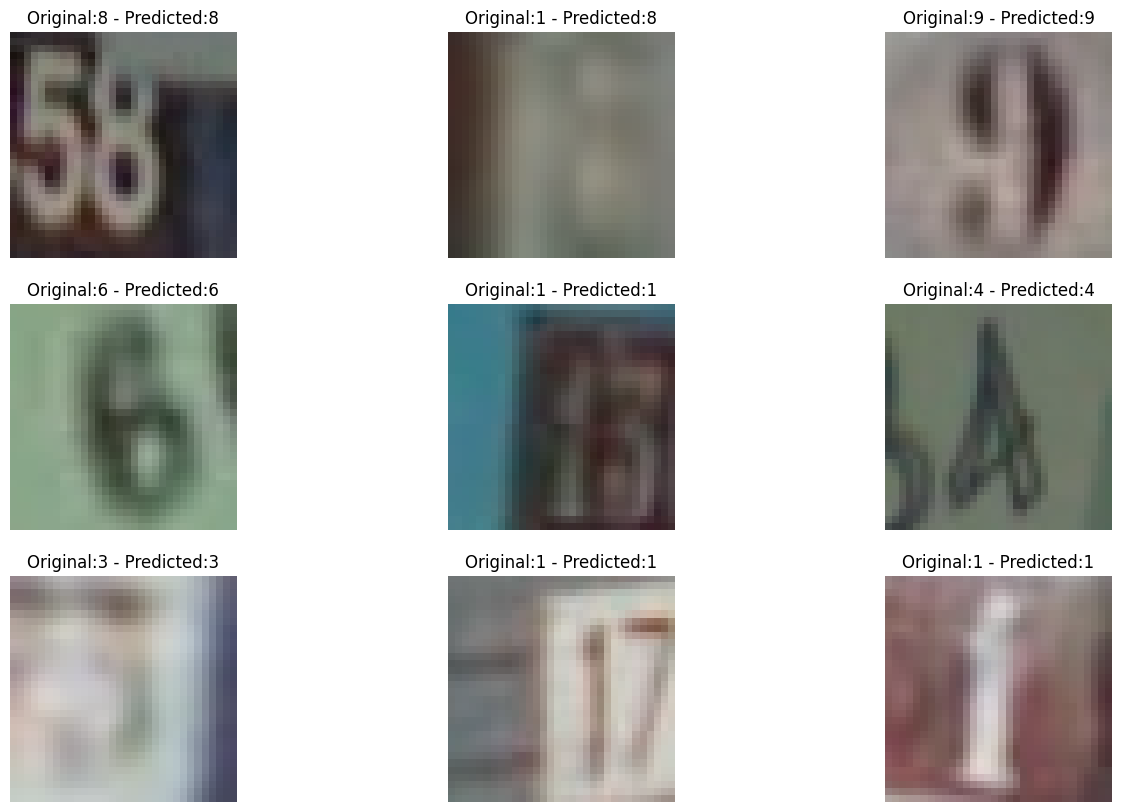

In [ ]:
# Plot a few clean test images with predicted labels
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(clean_x_test), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(clean_x_test[i[0]])
    plt.title('Original:' + str(names[int(clean_y_test[i[0]])]) + " - Predicted:" + str(names[clean_preds[i[0]]]))
    plt.axis('off')

# Plot at least 9 clean test images of digit 2 and show the original and predicted class label.

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


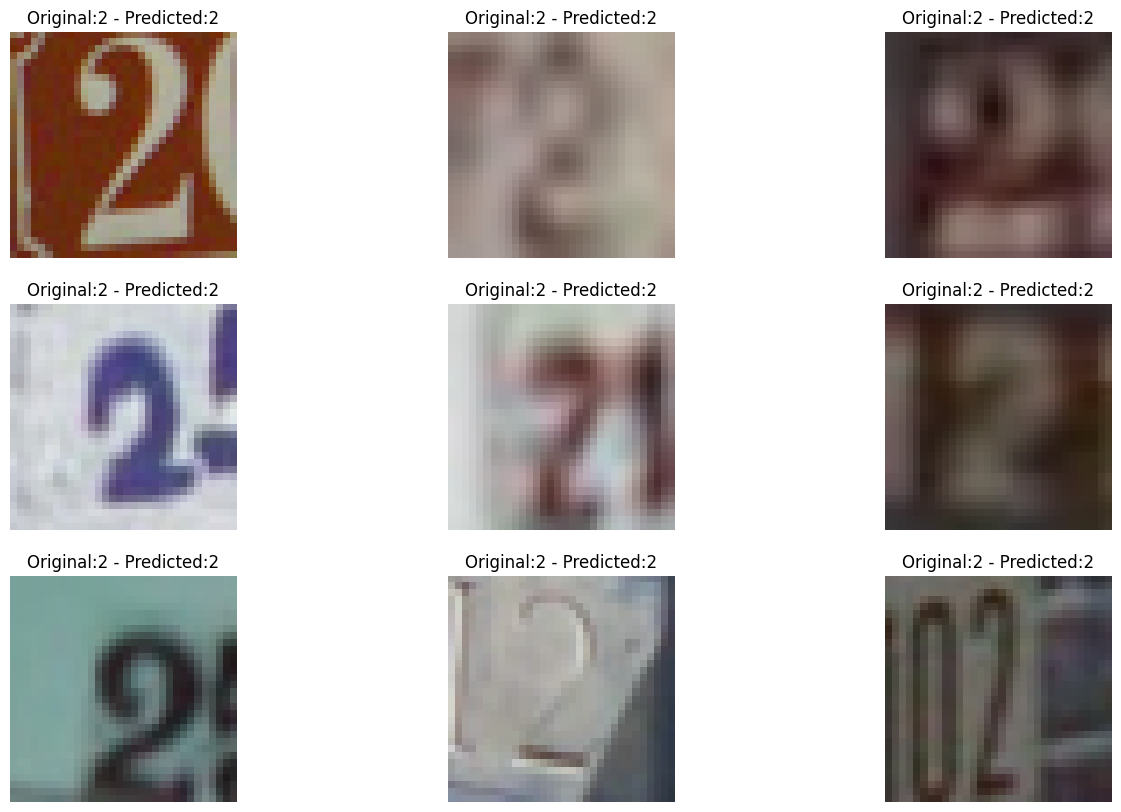

In [ ]:
# Plot a few clean test images that are benign
clean_x_test_2 = clean_x_test[clean_y_test==2]
clean_y_test_2 = clean_y_test[clean_y_test==2]
clean_preds_2 = np.argmax(model.predict(clean_x_test_2), axis=1)
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(clean_x_test_2), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(clean_x_test_2[i[0]])
    plt.title('Original:' + str(names[int(clean_y_test_2[i[0]])]) + " - Predicted:" + str(names[clean_preds_2[i[0]]]))
    plt.axis('off')

# Plot at least 9 clean test images of digit 5 and show the original and predicted class label.

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


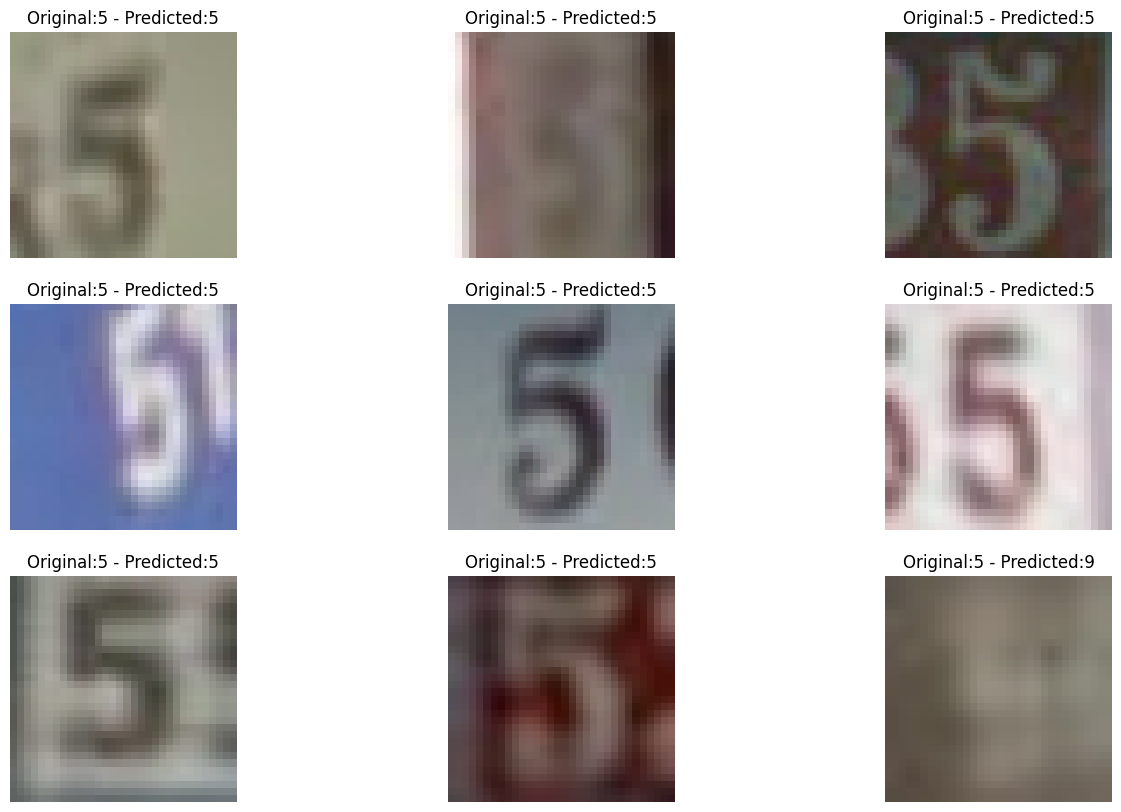

In [ ]:
# Plot a few clean test images that are malignant
clean_x_test_5 = clean_x_test[clean_y_test==5]
clean_y_test_5 = clean_y_test[clean_y_test==5]
clean_preds_5 = np.argmax(model.predict(clean_x_test_5), axis=1)
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(clean_x_test_5), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(clean_x_test_5[i[0]])
    plt.title('Original:' + str(names[int(clean_y_test_5[i[0]])]) + " - Predicted:" + str(names[clean_preds_5[i[0]]]))
    plt.axis('off')